In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
# matplotlib.use('Agg')
import datetime

%matplotlib inline
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer, data_split
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent
from stable_baselines3.common.logger import configure
from finrl.meta.data_processor import DataProcessor

from finrl.plot import backtest_stats, backtest_plot, get_daily_return, get_baseline
from pprint import pprint

import sys
sys.path.append("../FinRL")

import itertools

C:\Users\silve\anaconda3\envs\CM3070-FP\lib\site-packages\pyfolio\pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


warning above is not an issue since we are working with stocks, not futures so the multiplier is 1 by default.

In [2]:
from finrl import config
from finrl import config_tickers
import os
from finrl.main import check_and_make_directories
from finrl.config import (
    DATA_SAVE_DIR,
    TRAINED_MODEL_DIR,
    TENSORBOARD_LOG_DIR,
    RESULTS_DIR,
    INDICATORS,
    TRAIN_START_DATE,
    TRAIN_END_DATE,
    TEST_START_DATE,
    TEST_END_DATE,
    TRADE_START_DATE,
    TRADE_END_DATE,
)
check_and_make_directories([DATA_SAVE_DIR, TRAINED_MODEL_DIR, TENSORBOARD_LOG_DIR, RESULTS_DIR])

In [3]:
# from config.py, TRAIN_START_DATE is a string
TRAIN_START_DATE

'2014-01-06'

In [4]:
# from config.py, TRAIN_END_DATE is a string
TRAIN_END_DATE

'2020-07-31'

In [5]:
TODAY = datetime.datetime.today().strftime('%Y-%m-%d')

In [6]:
TRAIN_START_DATE = '2008-01-01'
TRAIN_END_DATE = '2023-01-01'
TRADE_START_DATE = '2023-01-01'
TRADE_END_DATE = TODAY

In [7]:
ticker_list = ['AAPL', 'AMGN', 'AMZN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS', 'GS', 'HD', 'HON', 'IBM', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 'MRK', 'MSFT', 'NKE', 'NVDA', 'PG', 'SWH', 'TRV', 'UNH', 'V', 'VZ', 'WMT']

In [8]:
df = YahooDownloader(start_date = TRAIN_START_DATE,
                     end_date = TRADE_END_DATE,
                     ticker_list = ticker_list).fetch_data()

YF deprecation warning: set proxy via new config function: yf.set_config(proxy=proxy)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Shape of DataFrame:  (130258, 8)


In [9]:
df

Price,date,close,high,low,open,volume,tic,day
0,2008-01-02,5.855755,6.018649,5.786932,5.988896,1079178800,AAPL,2
1,2008-01-02,32.223793,32.528054,31.988684,32.223793,7934400,AMGN,2
2,2008-01-02,4.812500,4.871500,4.735000,4.767500,277174000,AMZN,2
3,2008-01-02,38.800732,39.773790,38.610681,39.598944,8053700,AXP,2
4,2008-01-02,63.481609,64.375712,63.027225,64.177838,4303000,BA,2
...,...,...,...,...,...,...,...,...
130253,2025-07-16,252.190002,254.350006,250.210007,251.929993,1427900,TRV,2
130254,2025-07-16,292.489990,295.989990,290.750000,292.549988,9681800,UNH,2
130255,2025-07-16,349.899994,350.670013,345.799988,347.290009,5542500,V,2
130256,2025-07-16,41.250000,41.450001,41.160000,41.270000,17959200,VZ,2


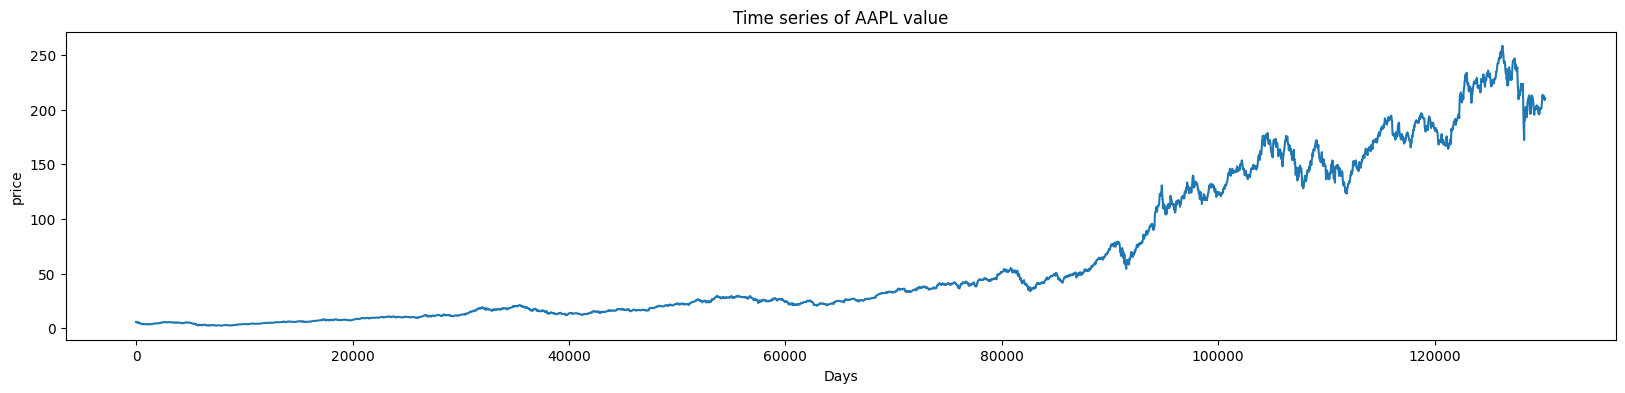

In [10]:
%matplotlib inline
# Create plot
fig, ax = plt.subplots(figsize=(20, 4))
ax.plot(df[df['tic'] == 'AAPL']['close'])
plt.title("Time series of AAPL value")
plt.xlabel("Days")
plt.ylabel("price")
plt.show()

In [11]:
df.columns

Index(['date', 'close', 'high', 'low', 'open', 'volume', 'tic', 'day'], dtype='object', name='Price')

In [12]:
fe = FeatureEngineer(
                    use_technical_indicator=True,
                    tech_indicator_list = INDICATORS,
                    use_vix=True,
                    use_turbulence=True,
                    user_defined_feature = False)

processed = fe.preprocess_data(df)

Successfully added technical indicators


[*********************100%***********************]  1 of 1 completed


Shape of DataFrame:  (4411, 8)
Successfully added vix
Successfully added turbulence index


In [13]:
list_ticker = processed["tic"].unique().tolist()
list_date = list(pd.date_range(processed['date'].min(),processed['date'].max()).astype(str))
combination = list(itertools.product(list_date,list_ticker))

processed_full = pd.DataFrame(combination,columns=["date","tic"]).merge(processed,on=["date","tic"],how="left")
processed_full = processed_full[processed_full['date'].isin(processed['date'])]
processed_full = processed_full.sort_values(['date','tic'])

processed_full = processed_full.fillna(0)

In [14]:
processed_full.sort_values(['date','tic'],ignore_index=True).head(20)

,date,tic,close,high,low,open,volume,day,macd,boll_ub,boll_lb,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma,vix,turbulence
0,2008-01-02,AAPL,5.855755,6.018649,5.786932,5.988896,1.079179e+09,2.0,0.0,5.860939,5.85328,100.0,-66.666667,100.0,5.855755,5.855755,23.17,0.0
1,2008-01-02,AMGN,32.223793,32.528054,31.988684,32.223793,7.934400e+06,2.0,0.0,5.860939,5.85328,100.0,-66.666667,100.0,32.223793,32.223793,23.17,0.0
2,2008-01-02,AMZN,4.812500,4.871500,4.735000,4.767500,2.771740e+08,2.0,0.0,5.860939,5.85328,100.0,-66.666667,100.0,4.812500,4.812500,23.17,0.0
3,2008-01-02,AXP,38.800732,39.773790,38.610681,39.598944,8.053700e+06,2.0,0.0,5.860939,5.85328,100.0,-66.666667,100.0,38.800732,38.800732,23.17,0.0
4,2008-01-02,BA,63.481609,64.375712,63.027225,64.177838,4.303000e+06,2.0,0.0,5.860939,5.85328,100.0,-66.666667,100.0,63.481609,63.481609,23.17,0.0
5,2008-01-02,CAT,44.507301,45.792802,44.141820,45.723486,6.337800e+06,2.0,0.0,5.860939,5.85328,100.0,-66.666667,100.0,44.507301,44.507301,23.17,0.0
6,2008-01-02,CRM,14.939095,15.749494,14.837486,15.625580,4.980000e+06,2.0,0.0,5.860939,5.85328,100.0,-66.666667,100.0,14.939095,14.939095,23.17,0.0
7,2008-01-02,CSCO,17.368881,17.866256,17.152914,17.669924,6.433890e+07,2.0,0.0,5.860939,5.85328,100.0,-66.666667,100.0,17.368881,17.368881,23.17,0.0
8,2008-01-02,CVX,47.075188,47.694732,46.697418,47.327034,9.058000e+06,2.0,0.0,5.860939,5.85328,100.0,-66.666667,100.0,47.075188,47.075188,23.17,0.0
9,2008-01-02,DIS,26.569569,27.228802,26.444398,26.970115,9.269900e+06,2.0,0.0,5.860939,5.85328,100.0,-66.666667,100.0,26.569569,26.569569,23.17,0.0


In [15]:
processed_full.columns

Index(['date', 'tic', 'close', 'high', 'low', 'open', 'volume', 'day', 'macd',
       'boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma',
       'close_60_sma', 'vix', 'turbulence'],
      dtype='object')

In [16]:
train = data_split(processed_full, TRAIN_START_DATE,TRAIN_END_DATE)
trade = data_split(processed_full, TRADE_START_DATE,TRADE_END_DATE)
print(len(train))
print(len(trade))

105756
17752


In [17]:
train.tail()

,date,tic,close,high,low,open,volume,day,macd,boll_ub,boll_lb,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma,vix,turbulence
3776,2022-12-30,PG,142.455322,143.508036,141.402609,143.273054,4532000.0,4.0,2.145568,144.649975,139.972084,60.748967,56.676168,22.094987,140.526265,132.137607,21.67,4.876599
3776,2022-12-30,TRV,178.542679,180.342484,177.552301,179.980614,608200.0,4.0,1.471267,182.047097,174.205419,56.428774,46.057020,6.869371,177.802379,171.649847,21.67,4.876599
3776,2022-12-30,UNH,508.466705,508.773607,503.345435,508.294084,1849600.0,4.0,-0.688360,526.036052,496.749422,50.390149,-30.048702,1.719191,509.770972,507.353229,21.67,4.876599
3776,2022-12-30,VZ,32.747986,32.989022,32.473699,32.673181,44007200.0,4.0,0.256559,32.831760,30.104205,53.943998,130.324096,28.954453,31.682977,31.242874,21.67,4.876599
3776,2022-12-30,WMT,45.765247,45.829804,45.448937,45.691013,11505900.0,4.0,-0.347775,49.112885,44.951407,48.559208,-121.727590,25.537630,47.634375,46.007580,21.67,4.876599


In [18]:
trade.head()

,date,tic,close,high,low,open,volume,day,macd,boll_ub,boll_lb,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma,vix,turbulence
0,2023-01-03,AAPL,123.470619,129.226060,122.582127,128.613993,112117500.0,1.0,-4.648598,147.860257,121.091849,39.011485,-130.963545,35.956403,138.293932,140.567287,22.9,48.045721
0,2023-01-03,AMGN,241.367706,242.244077,238.803204,240.648171,2594800.0,1.0,-3.707351,265.600940,233.467105,46.085247,-104.624950,29.740734,254.056495,248.620164,22.9,48.045721
0,2023-01-03,AMZN,85.820000,86.959999,84.209999,85.459999,76706000.0,1.0,-3.075118,93.357149,80.929850,41.195599,-71.360174,10.198927,89.424999,97.181000,22.9,48.045721
0,2023-01-03,AXP,142.092758,145.308971,140.750256,144.430063,2762200.0,1.0,-1.465139,153.895025,136.023649,47.808130,-62.042519,4.879735,146.382969,143.386904,22.9,48.045721
0,2023-01-03,BA,195.389999,197.179993,192.399994,192.949997,8624600.0,1.0,5.326285,196.702727,176.154272,62.905353,141.206999,44.456630,182.859667,166.269167,22.9,48.045721


In [19]:
trade.tail()

,date,tic,close,high,low,open,volume,day,macd,boll_ub,boll_lb,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma,vix,turbulence
633,2025-07-15,PG,152.679993,154.050003,151.899994,153.559998,9142600.0,1.0,-1.907700,163.402993,154.178010,39.041973,-208.161137,32.390222,160.472667,161.802717,17.379999,21.718082
633,2025-07-15,TRV,250.619995,254.160004,249.190002,253.500000,1424800.0,1.0,-3.397231,271.477945,250.875061,42.940599,-185.018707,34.050378,263.575216,264.744689,17.379999,21.718082
633,2025-07-15,UNH,291.709991,300.679993,291.029999,299.709991,16019000.0,1.0,-5.947759,318.779219,292.243779,37.287747,-156.394952,26.130943,304.788211,332.210785,17.379999,21.718082
633,2025-07-15,VZ,41.259998,41.630001,41.099998,41.439999,15653200.0,1.0,-0.193303,43.087693,40.656442,45.742319,-99.310857,17.587429,42.215482,42.445071,17.379999,21.718082
633,2025-07-15,WMT,95.389999,95.779999,94.940002,95.599998,10450800.0,1.0,-0.248474,99.642870,93.541129,49.014979,-74.231421,7.308131,96.873666,96.732238,17.379999,21.718082


In [20]:
INDICATORS

['macd',
 'boll_ub',
 'boll_lb',
 'rsi_30',
 'cci_30',
 'dx_30',
 'close_30_sma',
 'close_60_sma']

In [21]:
import reservoirpy as rpy
from reservoirpy.nodes import Reservoir, Ridge
from reservoirpy.observables import mse, nrmse, rmse
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

In [22]:
def normalize_data(train, test):
    data_min = min(train.min(), test.min())
    data_max = max(train.max(), test.max())
    return (train - data_min)/ (data_max - data_min), (test - data_min)/ (data_max - data_min), data_min, data_max

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    mse_score = mse(y_true, y_pred)
    rmse_score = rmse_val  # Change the variable name here
    nmrse_mean = nrmse(y_true, y_pred, norm_value=y_true.mean())
    nmrse_maxmin = nrmse(y_true, y_pred, norm_value=y_true.max() - y_true.min())
    r2 = r2_score(y_true, y_pred)
    return mae, rmse_score, mape, mse_score, rmse_score, nmrse_mean, nmrse_maxmin, r2

In [23]:
def filter_data(dataframe, ticker, column):
    return dataframe[dataframe['tic'] == ticker][column]

In [24]:
def create_lagged_dataset_from_full(x, x1, n_lags, horizon):
    full = np.concatenate([x, x1])  # Combine to maintain continuity

    X_all, y_all = [], []
    for i in range(len(full) - n_lags - horizon + 1):
        X_all.append(full[i:i + n_lags])
        y_all.append(full[i + n_lags + horizon - 1])

    X_all = np.array(X_all)
    y_all = np.array(y_all).reshape(-1, 1)

    # Determine split index: all points where inputs are from `x` only
    train_cutoff = len(x) - n_lags - horizon + 1

    X_train, y_train = X_all[:train_cutoff], y_all[:train_cutoff]
    X_test, y_test = X_all[train_cutoff:], y_all[train_cutoff:]

    return X_train, y_train, X_test, y_test

In [25]:
def train_rc_model(train, test, ticker, column, horizon):
    
    train = filter_data(train, ticker, column)
    test = filter_data(test, ticker, column)
    
    Dat = np.array(train)
    dat = np.array(test)

    # Set constants
    SEED = 42
    VERBOSE = True
    units = 10000
    z = horizon
    if __name__ == "__main__":
        rpy.set_seed(SEED)
        rpy.verbosity(0)

        if VERBOSE:
            print("Train", Dat.shape)
            print("max:", Dat.max(), "min:", Dat.min())
            print("mean:", Dat.mean(), "std:", Dat.std())

            print("Test", dat.shape)
            print("max:", dat.max(), "min:", dat.min())
            print("mean:", dat.mean(), "std:", dat.std())

        x, x1, minima, maxima = normalize_data(Dat, dat)

        n_lags = z

        X, y, X_test, y_test = create_lagged_dataset_from_full(x, x1, n_lags, z)
        
        #y = np.concatenate((x[z:], x1[:z])).reshape(-1, 1)
        #X_test = x1[:len(X1)-z].reshape(-1, 1)
        #y_test = x1[z:].reshape(-1, 1)
        #X = x.reshape(-1, 1)

        print(X.shape)
        print(y.shape)
        print(X_test.shape)
        print(y_test.shape)

        # Reservoir parameters
        units = 50
        leak_rate = 0.5
        rho = 1.0
        input_scaling = 1.0
        rc_connectivity = 0.15
        input_connectivity = 0.2
        fb_connectivity = 1.1
        regularization_coef = 1e-6
        warmup = 200
        feedback = False

        rng = np.random.default_rng(SEED)
        W = rng.random((units, units)) - 0.5
        input_bias = True  # Set to True or False depending on your choice
        Win = rng.random((units, 1 + int(input_bias))) - 0.5
        Wfb = rng.random((units, 1)) - 0.5

        mask = rng.random((units, units))
        W[mask > rc_connectivity] = 0

        mask = rng.random((units, Win.shape[1]))
        Win[mask > input_connectivity] = 0

        mask = rng.random((units, Wfb.shape[1]))
        Wfb[mask > fb_connectivity] = 0

        Win = Win * input_scaling

        # Calculate the spectral radius
        original_spectral_radius = np.max(np.abs(np.linalg.eigvals(W)))

        # Rescale the matrix to reach the requested spectral radius:
        W = W * (rho / original_spectral_radius)

        # Create a reservoir
        reservoir = Reservoir(
            units,
            lr=leak_rate,
            sr=rho,
            input_bias=input_bias,
            input_scaling=input_scaling,
            rc_connectivity=rc_connectivity,
            input_connectivity=input_connectivity,
            fb_connectivity=fb_connectivity,
        )

        readout = Ridge(ridge=regularization_coef)

        if feedback:
            reservoir = reservoir << readout

        esn = reservoir >> readout

        internal_trained = reservoir.run(X)

        reservoir.reset()

        plt.figure()
        plt.plot(internal_trained[:200, :21])
        plt.title("Activations $\\mathbf{x}(n)$ from Reservoir Neurons ID 0 to 20 for 200 time steps")
        plt.show()

        esn = esn.fit(X, y, warmup=warmup)

        y_pred = esn.run(X_test)

        mae, rmse, mape, mse_score, rmse_score, nmrse_mean, nmrse_maxmin, r2 = calculate_metrics(y_test, y_pred)

        print("Mean Absolute Error (MAE): {:.4f}".format(mae))
        print("Root Mean Squared Error (RMSE): {:.4f}".format(rmse))
        print("Mean Absolute Percentage Error (MAPE): {:.4f}%".format(mape))
        print("R-squared: {:.4f}".format(r2))
        print("\n********************")
        print(f"Errors computed over {len(X_test)} time steps")
        print("\nMean Squared error (MSE):\t%.4e" % mse_score)
        print("Root Mean Squared error (RMSE):\t%.4e" % rmse_score)
        print("Normalized RMSE (based on mean):\t%.4e" % nmrse_mean)
        print("Normalized RMSE (based on max - min):\t%.4e" % nmrse_maxmin)
        print("********************")

        plt.figure(figsize=(16, 6))
        plt.plot(y_pred, color="red", lw=1.5, label="Predictions")
        plt.plot(y_test, color="blue", lw=0.75, label="Ground truth")
        plt.title("Prediction with Reservoir Computing")
        plt.legend()
        plt.show()

        return esn      

Train (3777,)
max: 178.6456298828125 min: 2.3502373695373535
mean: 42.887608199388474 std: 46.474719917102895
Test (634,)
max: 258.39666748046875 min: 123.42125701904297
mean: 194.31149137960247 std: 28.426530024684943
(3776, 1)
(3776, 1)
(634, 1)
(634, 1)


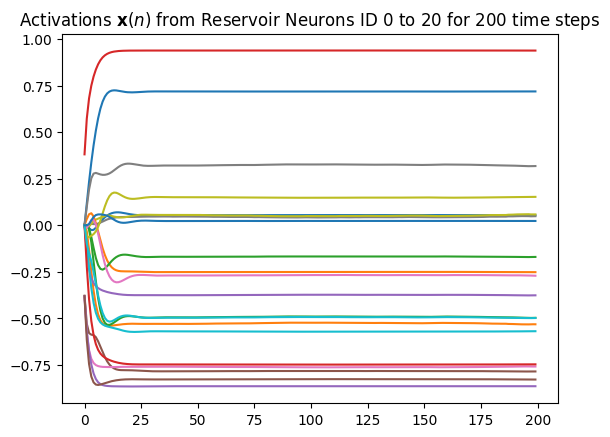

Mean Absolute Error (MAE): 0.0104
Root Mean Squared Error (RMSE): 0.0141
Mean Absolute Percentage Error (MAPE): 1.3757%
R-squared: 0.9839

********************
Errors computed over 634 time steps

Mean Squared error (MSE):	1.9864e-04
Root Mean Squared error (RMSE):	1.4094e-02
Normalized RMSE (based on mean):	1.8799e-02
Normalized RMSE (based on max - min):	2.6736e-02
********************


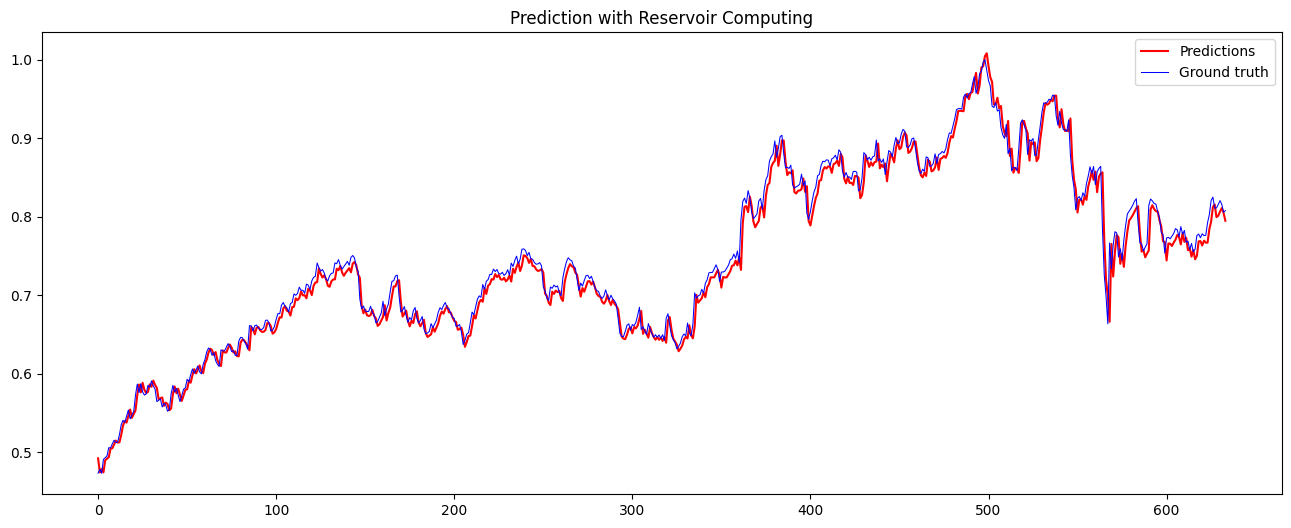

In [26]:
AAPL = train_rc_model(train, trade, 'AAPL', 'close', 1)

Train (3777,)
max: 267.87982177734375 min: 27.639169692993164
mean: 112.50724006816449 std: 64.15200272524939
Test (634,)
max: 329.1125183105469 min: 201.28501892089844
mean: 268.99250475766155 std: 34.110514955214754
(3776, 1)
(3776, 1)
(634, 1)
(634, 1)


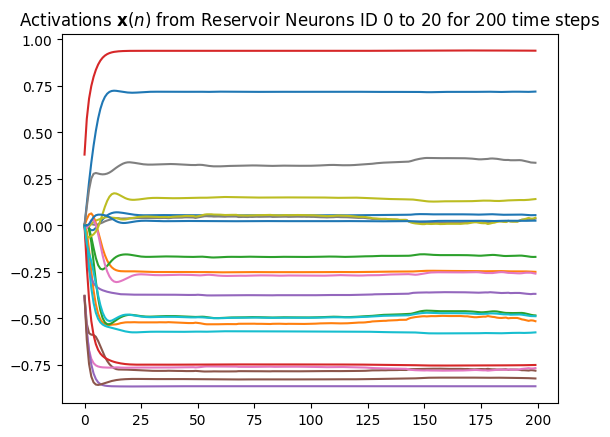

Mean Absolute Error (MAE): 0.0108
Root Mean Squared Error (RMSE): 0.0155
Mean Absolute Percentage Error (MAPE): 1.3298%
R-squared: 0.9811

********************
Errors computed over 634 time steps

Mean Squared error (MSE):	2.4139e-04
Root Mean Squared error (RMSE):	1.5537e-02
Normalized RMSE (based on mean):	1.9407e-02
Normalized RMSE (based on max - min):	3.6642e-02
********************


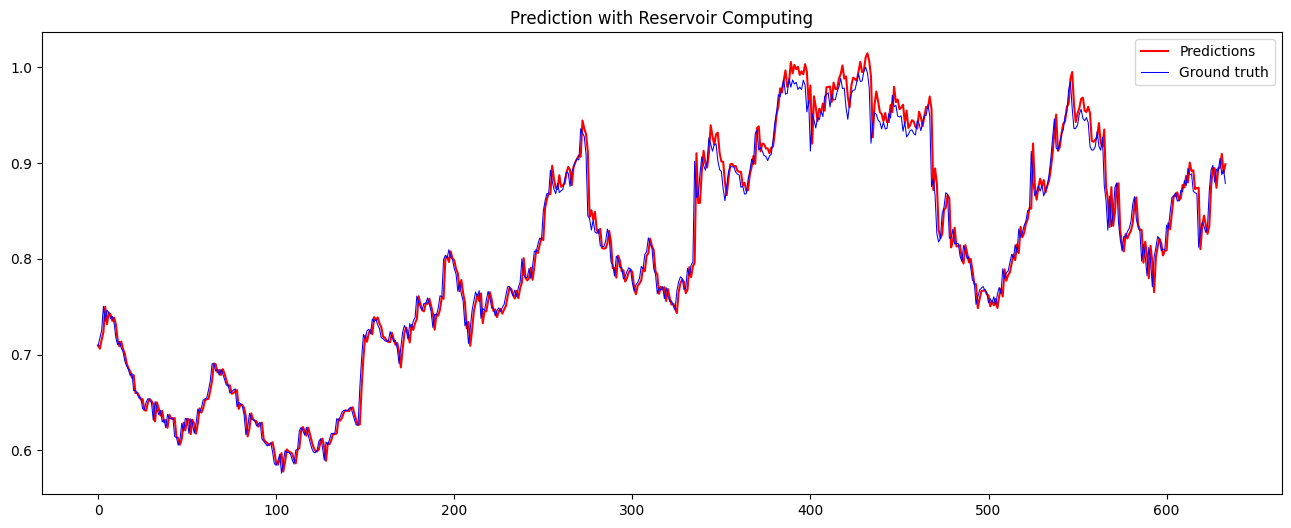

In [27]:
AMGN = train_rc_model(train, trade, 'AMGN', 'close', 1)

In [28]:
ticker_list

['AAPL',
 'AMGN',
 'AMZN',
 'AXP',
 'BA',
 'CAT',
 'CRM',
 'CSCO',
 'CVX',
 'DIS',
 'GS',
 'HD',
 'HON',
 'IBM',
 'JNJ',
 'JPM',
 'KO',
 'MCD',
 'MMM',
 'MRK',
 'MSFT',
 'NKE',
 'NVDA',
 'PG',
 'SWH',
 'TRV',
 'UNH',
 'V',
 'VZ',
 'WMT']

In [29]:
for x in ticker_list:
    rc = 

SyntaxError: invalid syntax (4002686878.py, line 2)

In [30]:
close_df = processed_full.pivot_table(index='date', columns='tic', values='close', aggfunc='mean')
close_df

tic,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MMM,MRK,MSFT,NKE,NVDA,PG,TRV,UNH,VZ,WMT
date,,,,,,,,,,,,,,,,,,,,,
2008-01-02,5.855755,32.223793,4.812500,38.800732,63.481609,44.507301,14.939095,17.368881,47.075188,26.569569,...,40.633366,29.543840,25.340912,12.551368,0.756702,43.636883,34.426796,44.683479,16.196831,10.829197
2008-01-03,5.858463,31.594528,4.760500,38.321796,63.745430,44.349766,15.112576,17.506315,47.654438,26.511158,...,40.628479,29.518101,25.448851,12.438308,0.750742,43.636883,34.887054,44.888489,16.271797,10.709126
2008-01-04,5.411256,30.979115,4.439500,37.356350,62.895332,43.183987,14.587180,17.094019,47.019783,25.977095,...,40.166676,29.276064,24.736538,12.245914,0.687703,43.461864,33.789021,44.155201,15.968179,10.556733
2008-01-07,5.338826,31.387072,4.441000,37.523590,60.733334,43.310040,14.314568,17.100561,46.405300,26.002131,...,39.847336,29.827076,24.902016,12.319304,0.616640,43.745502,34.216400,44.849060,16.249304,10.750689
2008-01-08,5.146779,32.037090,4.394000,36.451702,58.564037,42.314400,13.556213,16.642450,45.810913,25.484756,...,39.405197,30.723125,24.067394,12.263764,0.629706,43.860149,33.170975,44.320789,15.897214,10.614459
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-09,211.139999,296.519989,222.539993,317.350006,226.600006,402.179993,270.920013,69.269997,153.020004,120.610001,...,155.979996,83.709999,503.510010,73.559998,162.880005,157.520004,255.320007,302.910004,41.931999,96.809998
2025-07-10,212.410004,300.369995,222.259995,325.239990,226.089996,408.329987,263.970001,68.760002,154.169998,121.559998,...,157.320007,84.019997,501.480011,74.620003,164.100006,158.490005,255.990005,299.510010,42.029999,94.860001
2025-07-11,211.160004,295.269989,225.020004,319.470001,226.839996,405.920013,258.070007,67.949997,155.309998,119.870003,...,155.839996,83.360001,503.320007,72.629997,164.919998,157.050003,254.479996,304.100006,41.619999,94.400002


In [31]:
def normalize_data(data):
    return (data - data.min()) / (data.max() - data.min())

In [32]:
def create_windowed_dataset(data, window, horizon):
    X, y = [], []
    for i in range(len(data) - window - horizon):
        X.append(data[i : i + window])
        y.append(data[i + window + horizon - 1])  # Predict horizon steps ahead
    return np.array(X), np.array(y)

Data dimensions (4411, 28)
max: 723.6799926757812 min: 0.13524821400642395
mean: 94.03840013659587 std: 88.12588541350759


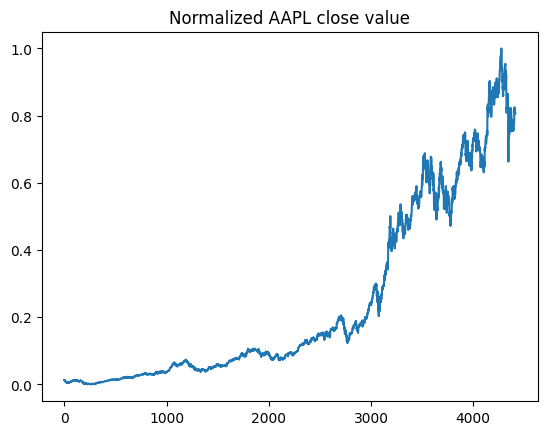

(1000, 1)
(1000, 1)
(100, 1)
(100, 1)


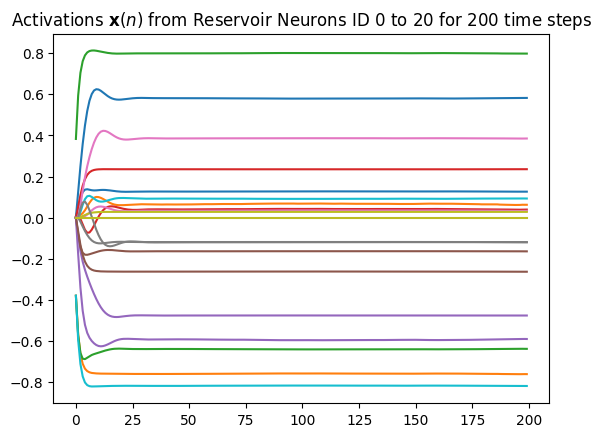

Mean Absolute Error (MAE): 0.0009
Root Mean Squared Error (RMSE): 0.0013
Mean Absolute Percentage Error (MAPE): 1.6911%
R-squared: 0.9790

********************
Errors computed over 100 time steps

Mean Squared error (MSE):	1.6900e-06
Root Mean Squared error (RMSE):	1.3000e-03
Normalized RMSE (based on mean):	2.4911e-02
Normalized RMSE (based on max - min):	4.6093e-02
********************


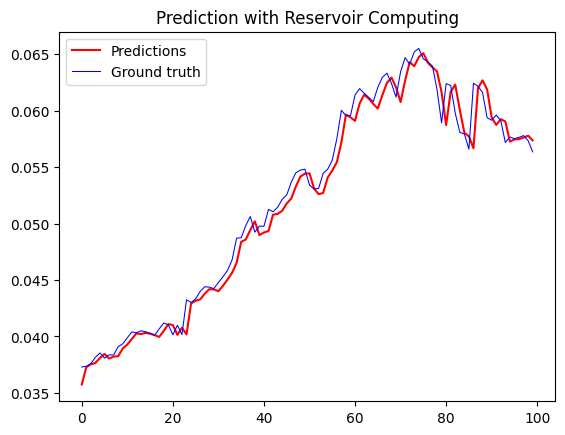

In [46]:
from sklearn.preprocessing import MinMaxScaler
df=close_df
Dat = np.array(df)

# Set constants
window = 10
SEED = 42
VERBOSE = True
units = 10000
horizon = 1

if __name__ == "__main__":
    rpy.set_seed(SEED)
    rpy.verbosity(0)

    if VERBOSE:
        print("Data dimensions", Dat.shape)
        print("max:", Dat.max(), "min:", Dat.min())
        print("mean:", Dat.mean(), "std:", Dat.std())

    #data = normalize_data(Dat[:,0])
    #data = Dat[:,0]
    data = Dat[:,0].reshape(-1, 1)
    scaler = MinMaxScaler(feature_range = (0,1)).fit(data)
    data = scaler.transform(data)
    
    plt.figure()
    plt.plot(data)
    plt.title("Normalized AAPL close value")
    plt.show()

    train_size = 1000
    test_size = 100

    X = data[:train_size].reshape(-1, 1)
    y = data[horizon : train_size + horizon].reshape(-1, 1)
    X_test = data[train_size : train_size + test_size].reshape(-1, 1)
    y_test = data[train_size + horizon : train_size + test_size + horizon].reshape(-1, 1)

    # Generate dataset with window
    #X_all, y_all = create_windowed_dataset(data, window, horizon)

    #X = X_all[:train_size]
    #y = y_all[:train_size].reshape(-1, 1)

    #X_test = X_all[train_size:]
    #y_test = y_all[train_size:].reshape(-1, 1)

    # Generate dataset with indices
    

    print(X.shape)
    print(y.shape)
    print(X_test.shape)
    print(y_test.shape)

    # Reservoir parameters
    units = 20
    leak_rate = 0.5
    rho = 1.0
    input_scaling = 0.75
    rc_connectivity = 0.15
    input_connectivity = 0.2
    fb_connectivity = 1.1
    regularization_coef = 1e-6
    warmup = 200
    feedback = False

    rng = np.random.default_rng(SEED)
    W = rng.random((units, units)) - 0.5
    input_bias = True  # Set to True or False depending on your choice
    Win = rng.random((units, 1 + int(input_bias))) - 0.5
    Wfb = rng.random((units, 1)) - 0.5

    mask = rng.random((units, units))
    W[mask > rc_connectivity] = 0

    mask = rng.random((units, Win.shape[1]))
    Win[mask > input_connectivity] = 0

    mask = rng.random((units, Wfb.shape[1]))
    Wfb[mask > fb_connectivity] = 0

    Win = Win * input_scaling

    # Calculate the spectral radius
    original_spectral_radius = np.max(np.abs(np.linalg.eigvals(W)))

    # Rescale the matrix to reach the requested spectral radius:
    W = W * (rho / original_spectral_radius)

    # Create a reservoir
    reservoir = Reservoir(
        units,
        lr=leak_rate,
        sr=rho,
        input_bias=input_bias,
        input_scaling=input_scaling,
        rc_connectivity=rc_connectivity,
        input_connectivity=input_connectivity,
        fb_connectivity=fb_connectivity,
    )

    readout = Ridge(ridge=regularization_coef)

    if feedback:
        reservoir = reservoir << readout

    esn = reservoir >> readout

    internal_trained = reservoir.run(X)

    reservoir.reset()

    plt.figure()
    plt.plot(internal_trained[:200, :21])
    plt.title("Activations $\\mathbf{x}(n)$ from Reservoir Neurons ID 0 to 20 for 200 time steps")
    plt.show()

    esn = esn.fit(X, y, warmup=warmup)

    y_pred = esn.run(X_test)

    mae, rmse, mape, mse_score, rmse_score, nmrse_mean, nmrse_maxmin, r2 = calculate_metrics(y_test, y_pred)

    print("Mean Absolute Error (MAE): {:.4f}".format(mae))
    print("Root Mean Squared Error (RMSE): {:.4f}".format(rmse))
    print("Mean Absolute Percentage Error (MAPE): {:.4f}%".format(mape))
    print("R-squared: {:.4f}".format(r2))
    print("\n********************")
    print(f"Errors computed over {test_size} time steps")
    print("\nMean Squared error (MSE):\t%.4e" % mse_score)
    print("Root Mean Squared error (RMSE):\t%.4e" % rmse_score)
    print("Normalized RMSE (based on mean):\t%.4e" % nmrse_mean)
    print("Normalized RMSE (based on max - min):\t%.4e" % nmrse_maxmin)
    print("********************")

    plt.figure()
    plt.plot(y_pred, color="red", lw=1.5, label="Predictions")
    plt.plot(y_test, color="blue", lw=0.75, label="Ground truth")
    plt.title("Prediction with Reservoir Computing")
    plt.legend()
    plt.show()

end_time = time.time()

In [47]:
Dat[:,0].shape

(4411,)

In [48]:
data.shape

(4411, 1)

In [ ]:
y_test

In [ ]:
y_pred

In [39]:
Dat.shape

(4411, 28)